## Carbohydrate Metabolism

One of the prevailing health result from obesity is alteration of metabolism. Particularly, glucose or carbohydrate metabolism is affected, resulting in diabetes mellitus. The next set of labs that will be analyzed are:
* blood glucose (fasting)
* insulin
* hemoglobin A1c.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import math
import scipy.stats as stats
from math import erf, sqrt
from math import atanh, sqrt

In [2]:
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_d = pd.read_csv('cleaned_demographics.csv')
df_i = pd.read_csv('insulin.csv')
df_h = pd.read_csv('hgb_a1c.csv')
df_g = pd.read_csv('fasting_glucose.csv')

In [3]:
df_a.head()

,participant_id,weight_kg,weight_comment,recumbent_length_cm,standing_height,standing_height_comment,bmi,bmi_category_child,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109264.0,42.2,NaN,NaN,154.7,NaN,17.6,2.0,36.3,33.8,22.7,63.8,85.0
1,109265.0,12.0,NaN,91.6,89.3,NaN,15.0,2.0,NaN,18.6,14.8,41.2,NaN
2,109266.0,97.1,NaN,NaN,160.2,NaN,37.8,NaN,40.8,34.7,35.8,117.9,126.1
3,109269.0,13.6,NaN,90.9,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109270.0,75.3,NaN,NaN,156.0,NaN,30.9,4.0,42.6,36.1,31.0,91.4,NaN


In [4]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [5]:
df_a = df_a.drop(['weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment','bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'], axis=1)

In [6]:
df_a.head()

,participant_id,bmi
0,109264.0,17.6
1,109265.0,15.0
2,109266.0,37.8
3,109269.0,NaN
4,109270.0,30.9


In [7]:
df_a.isna().sum()

participant_id      0
bmi               970
dtype: int64

In [8]:
df_a = df_a.dropna(subset=['bmi'])

In [9]:
df_a.isna().sum()

participant_id    0
bmi               0
dtype: int64

In [10]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [11]:
df = df_a.merge(df_d, on = 'participant_id')

In [12]:
df.head()

,participant_id,bmi,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109264.0,17.6,2.0,13.0,1.0,NaN,NaN,0.83
1,109265.0,15.0,1.0,2.0,3.0,NaN,NaN,3.06
2,109266.0,37.8,2.0,29.0,6.0,5.0,3.0,5.00
3,109270.0,30.9,2.0,11.0,4.0,NaN,NaN,1.88
4,109271.0,29.7,1.0,49.0,3.0,2.0,3.0,NaN


In [13]:
df.isna().sum()

participant_id              0
bmi                         0
gender                      0
age_year                    0
race                        0
education_level          4756
marital_status           4756
family_income_poverty    1694
dtype: int64

In [14]:
df = df.drop(['education_level','marital_status','family_income_poverty'], axis=1)

### Fasting Glucose

Fasting glucose is a way to gauge carbohydrate metabolism. The ranges for the fasting glucose levels are as follows:
* Normal: <100 mg/dL
* Prediabetes: 100-125 mg/dL
* Diabetes: >125 mg/dL

In [15]:
df_g.head()

,Unnamed: 0,participant_id,fasting_glucose_mg_dl,fasting_glucose_mmol_l
0,0,109264.0,97.0,5.38
1,1,109271.0,103.0,5.72
2,2,109274.0,154.0,8.55
3,3,109277.0,92.0,5.11
4,4,109282.0,95.0,5.27


In [16]:
df_g = df_g.drop(['Unnamed: 0','fasting_glucose_mmol_l'], axis=1)

In [17]:
df = df.merge(df_g, on='participant_id')

In [18]:
df.head()

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl
0,109264.0,17.6,2.0,13.0,1.0,97.0
1,109271.0,29.7,1.0,49.0,3.0,103.0
2,109274.0,30.2,1.0,68.0,7.0,154.0
3,109277.0,18.6,2.0,12.0,1.0,92.0
4,109282.0,26.6,1.0,76.0,3.0,95.0


In [19]:
df.describe()

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,4985.000000,4985.000000,4985.000000,4985.000000,4985.000000,4659.000000
mean,117172.084052,29.130110,1.515547,45.031494,3.497693,111.044859
std,4481.456064,7.805949,0.499808,20.659580,1.623477,36.131795
min,109264.000000,14.600000,1.000000,12.000000,1.000000,47.000000
25%,113328.000000,23.800000,1.000000,26.000000,3.000000,95.000000
50%,117243.000000,27.900000,2.000000,46.000000,3.000000,102.000000
75%,121041.000000,33.000000,2.000000,62.000000,4.000000,112.000000
max,124822.000000,92.300000,2.000000,80.000000,7.000000,524.000000


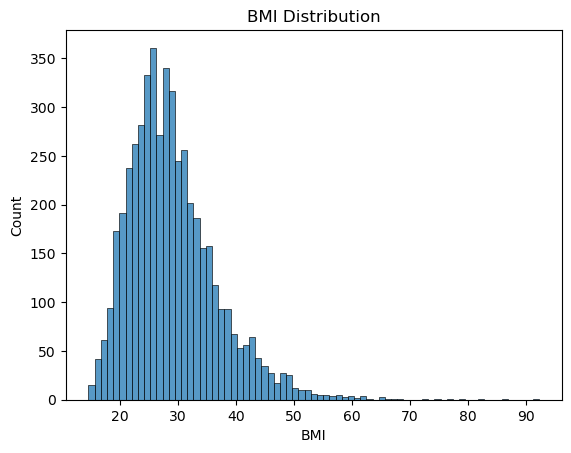

In [20]:
sns.histplot(data=df, x='bmi')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

In [21]:
df['bmi'].quantile([0.95, 0.99])

0.95    43.600
0.99    53.132
Name: bmi, dtype: float64

BMI is right skewed with minimum at 14 and maximum at 92. in the 99th percentile, the value is at 52. The 92 is an extreme outlier which is biologically/physiologically possible but extremely rare. The decision was made to keep all the BMI values for data integrity.

In [22]:
df.isna().sum()

participant_id             0
bmi                        0
gender                     0
age_year                   0
race                       0
fasting_glucose_mg_dl    326
dtype: int64

In [23]:
df = df.dropna(subset=['fasting_glucose_mg_dl'])

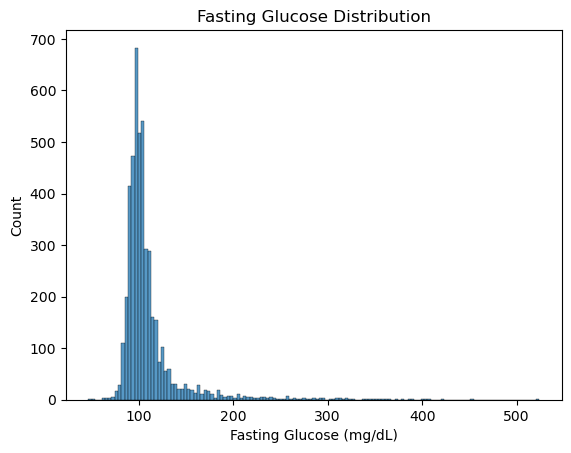

In [24]:
sns.histplot(data=df, x='fasting_glucose_mg_dl')
plt.title('Fasting Glucose Distribution')
plt.xlabel('Fasting Glucose (mg/dL)')
plt.ylabel('Count')
plt.show()

#the histogram looks a little right skewed but it looks fairly normally distributed

In [25]:
df.describe()

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,4659.000000,4659.000000,4659.000000,4659.000000,4659.000000,4659.000000
mean,117145.050440,29.153595,1.514273,45.377978,3.479287,111.044859
std,4476.661666,7.701039,0.499850,20.504413,1.632955,36.131795
min,109264.000000,14.600000,1.000000,12.000000,1.000000,47.000000
25%,113300.500000,23.900000,1.000000,27.000000,3.000000,95.000000
50%,117196.000000,27.900000,2.000000,46.000000,3.000000,102.000000
75%,120990.000000,33.000000,2.000000,62.000000,4.000000,112.000000
max,124822.000000,92.300000,2.000000,80.000000,7.000000,524.000000


In [26]:
df['fasting_glucose_mg_dl'].median()

102.0

In [27]:
df['fasting_glucose_mg_dl'].skew()

np.float64(4.319883148182733)

In [28]:
df['fasting_glucose_mg_dl'].quantile([0.95, 0.99])

0.95    171.00
0.99    291.42
Name: fasting_glucose_mg_dl, dtype: float64

Fasting glucose of over 500 mg/dL is not common but physiologically possible. The decision was made to keep all the data points for data integrity. 

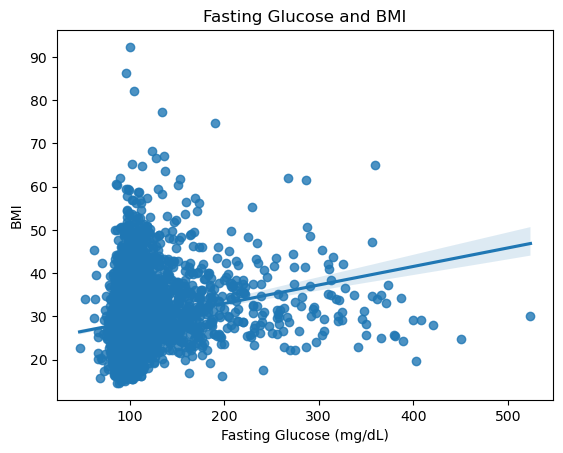

In [29]:
sns.regplot(data=df, x='fasting_glucose_mg_dl',y='bmi')
plt.title("Fasting Glucose and BMI")
plt.xlabel('Fasting Glucose (mg/dL)')
plt.ylabel('BMI')
plt.show()

Fasting glucose and BMI seem to have a positive correlation.

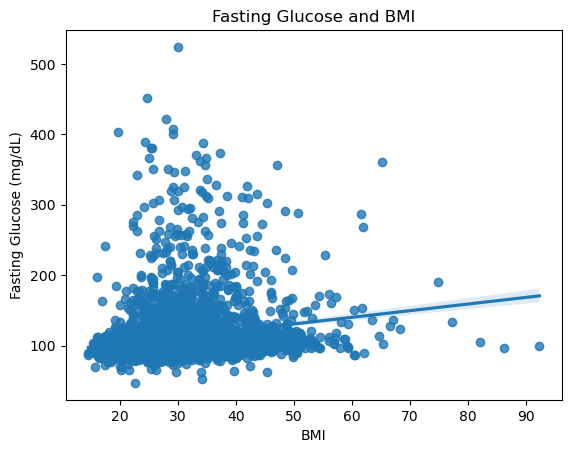

In [30]:
sns.regplot(data=df, x='bmi',y='fasting_glucose_mg_dl')
plt.title("Fasting Glucose and BMI")
plt.ylabel('Fasting Glucose (mg/dL)')
plt.xlabel('BMI')
plt.show()

With BMI as the independent variable, the correlation is the same with fasting glucose which makes sense. The general trend is that the higher the BMI, the higher the fasting glucose levels. 

Although the data distribution is skewed, due to the large sample size and seemingly linear correlation, Pearson correlation test would be the test of choice. Correlation coefficient is 0.2, which shows a weak positive correlation between BMI and fasting glucose levels. The p value is 1.17e-43, which shows statistical significance in the relationship.

In [31]:
df[['bmi','fasting_glucose_mg_dl']].corr()

,bmi,fasting_glucose_mg_dl
bmi,1.000000,0.200971
fasting_glucose_mg_dl,0.200971,1.000000


In [32]:
stats.pearsonr(df['bmi'],df['fasting_glucose_mg_dl'])

PearsonRResult(statistic=np.float64(0.20097053871169318), pvalue=np.float64(1.1778565116161735e-43))

#### Males

In [33]:
df['gender'].value_counts()

gender
2.0    2396
1.0    2263
Name: count, dtype: int64

In [34]:
df['gender_label'] = df['gender'].map({1:'Male',2:'Female'})

In [35]:
df.describe(include='all')

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl,gender_label
count,4659.000000,4659.000000,4659.000000,4659.000000,4659.000000,4659.000000,4659
unique,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,Female
freq,NaN,NaN,NaN,NaN,NaN,NaN,2396
mean,117145.050440,29.153595,1.514273,45.377978,3.479287,111.044859,NaN
std,4476.661666,7.701039,0.499850,20.504413,1.632955,36.131795,NaN
min,109264.000000,14.600000,1.000000,12.000000,1.000000,47.000000,NaN
25%,113300.500000,23.900000,1.000000,27.000000,3.000000,95.000000,NaN
50%,117196.000000,27.900000,2.000000,46.000000,3.000000,102.000000,NaN
75%,120990.000000,33.000000,2.000000,62.000000,4.000000,112.000000,NaN


In [36]:
df_male = df[df['gender_label']=='Male']
df_female = df[df['gender_label']=='Female']

In [37]:
df_male.describe(include='all')

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl,gender_label
count,2263.000000,2263.000000,2263.0,2263.000000,2263.000000,2263.000000,2263
unique,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,Male
freq,NaN,NaN,NaN,NaN,NaN,NaN,2263
mean,117230.200619,28.282369,1.0,45.629695,3.471498,113.623951,NaN
std,4470.349111,6.618134,0.0,20.891468,1.634334,38.236473,NaN
min,109271.000000,14.600000,1.0,12.000000,1.000000,64.000000,NaN
25%,113369.000000,23.900000,1.0,26.000000,3.000000,97.000000,NaN
50%,117383.000000,27.500000,1.0,47.000000,3.000000,103.000000,NaN
75%,121070.000000,31.600000,1.0,63.000000,4.000000,114.000000,NaN


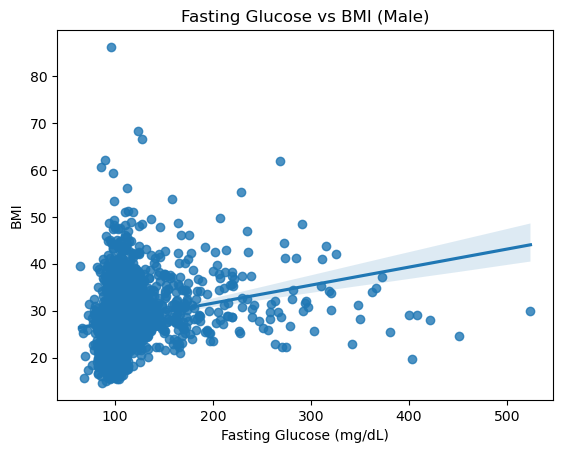

In [38]:
sns.regplot(data=df_male, x='fasting_glucose_mg_dl', y='bmi')
plt.title('Fasting Glucose vs BMI (Male)')
plt.xlabel('Fasting Glucose (mg/dL)')
plt.ylabel('BMI')
plt.show()

In [39]:
df_male[['fasting_glucose_mg_dl','bmi']].corr()

,fasting_glucose_mg_dl,bmi
fasting_glucose_mg_dl,1.000000,0.221826
bmi,0.221826,1.000000


In [40]:
df_male['fasting_glucose_mg_dl'].quantile([0.95, 0.99])

0.95    175.00
0.99    294.38
Name: fasting_glucose_mg_dl, dtype: float64

In [41]:
stats.pearsonr(df_male['fasting_glucose_mg_dl'], df_male['bmi'])

PearsonRResult(statistic=np.float64(0.22182554888196643), pvalue=np.float64(1.2633199026717776e-26))

#### Female

In [42]:
df_female.describe()

,participant_id,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,2396.000000,2396.000000,2396.0,2396.000000,2396.000000,2396.000000
mean,117064.626878,29.976461,2.0,45.140234,3.486644,108.608932
std,4482.062899,8.519470,0.0,20.133489,1.631958,33.852638
min,109264.000000,14.600000,2.0,12.000000,1.000000,47.000000
25%,113245.500000,23.975000,2.0,28.000000,3.000000,93.000000
50%,117045.500000,28.400000,2.0,46.000000,3.000000,100.000000
75%,120875.500000,34.400000,2.0,61.000000,4.000000,110.000000
max,124813.000000,92.300000,2.0,80.000000,7.000000,389.000000


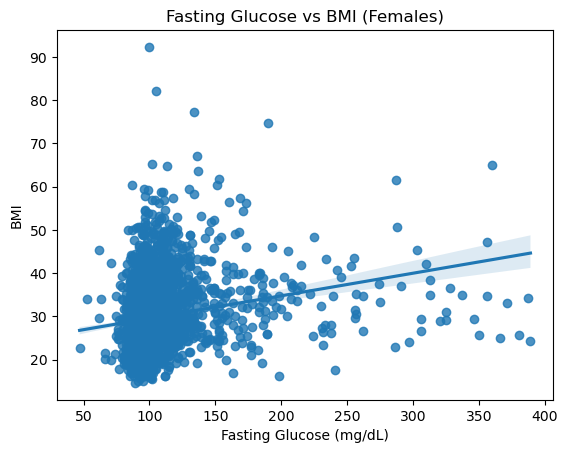

In [43]:
sns.regplot(data=df_female,x='fasting_glucose_mg_dl',y='bmi')
plt.title('Fasting Glucose vs BMI (Females)')
plt.xlabel('Fasting Glucose (mg/dL)')
plt.ylabel('BMI')
plt.show()

In [44]:
df_female['fasting_glucose_mg_dl'].quantile([0.95,0.99])

0.95    163.00
0.99    287.05
Name: fasting_glucose_mg_dl, dtype: float64

In [45]:
stats.pearsonr(df_female['fasting_glucose_mg_dl'],df_female['bmi'])

PearsonRResult(statistic=np.float64(0.20759166492536857), pvalue=np.float64(9.80730897982074e-25))

In [46]:
df_female[['fasting_glucose_mg_dl','bmi']].corr()

,fasting_glucose_mg_dl,bmi
fasting_glucose_mg_dl,1.000000,0.207592
bmi,0.207592,1.000000


Fasting glucose average is higher in the male population than the female population. However, the BMI is higher in the female population. 

The correlation coefficient is about the same, although the males have a slightly higher positive correlation between BMI and fasting glucose (0.22 vs 0.20). However, the difference is negligible and insignificant. The biological sex of the cohort did not have a significant impact on the relationship between the BMI and fasting glucose levels. 

### Fasting Insulin

Insulin is a hormone that is secreted for blood sugar regulation. It helps to move the sugar in the bloodstream into cells so that the energy can be utilized. 

Obese population generally has insulin resistance due to the high volume of adiposity. When there is insulin resistance, there is a lot of insulin that gets produced. The tissues are not as responsive to the hormone for sugar uptake.

The NHANES dataset collected fasting insulin levels. According to Up to Date, normal serum fasting insulin level is <20 microunits/mL; <138.9 pmol/L (SI).

In [47]:
df_i.head()

,Unnamed: 0,participant_id,insulin_μu_ml,insulin_pmol_l,insulin_comment_code
0,0,109264.0,6.05,36.30,0.0
1,1,109271.0,16.96,101.76,0.0
2,2,109274.0,13.52,81.12,0.0
3,3,109277.0,6.44,38.64,0.0
4,4,109282.0,7.49,44.94,0.0


In [48]:
df_i = df_i.drop(['Unnamed: 0',	'insulin_comment_code'] , axis=1)

In [49]:
df_i.head()

,participant_id,insulin_μu_ml,insulin_pmol_l
0,109264.0,6.05,36.30
1,109271.0,16.96,101.76
2,109274.0,13.52,81.12
3,109277.0,6.44,38.64
4,109282.0,7.49,44.94


In [50]:
df_i.isna().sum()

participant_id      0
insulin_μu_ml     465
insulin_pmol_l    465
dtype: int64

In [51]:
df_i = df_i.dropna(subset=['insulin_μu_ml'])

In [52]:
df_i.describe()

,participant_id,insulin_μu_ml,insulin_pmol_l
count,4625.000000,4625.000000,4625.000000
mean,117146.725622,14.962549,89.575619
std,4481.637915,22.847772,133.264127
min,108368.000000,0.460000,4.260000
25%,113285.000000,6.310000,37.860000
50%,117204.000000,10.110000,61.080000
75%,120979.000000,16.610000,99.660000
max,124822.000000,512.500000,3075.000000


In [53]:
df_i = df_i.merge(df, on='participant_id')

In [54]:
df_i.head()

,participant_id,insulin_μu_ml,insulin_pmol_l,bmi,gender,age_year,race,fasting_glucose_mg_dl,gender_label
0,109264.0,6.05,36.30,17.6,2.0,13.0,1.0,97.0,Female
1,109271.0,16.96,101.76,29.7,1.0,49.0,3.0,103.0,Male
2,109274.0,13.52,81.12,30.2,1.0,68.0,7.0,154.0,Male
3,109277.0,6.44,38.64,18.6,2.0,12.0,1.0,92.0,Female
4,109282.0,7.49,44.94,26.6,1.0,76.0,3.0,95.0,Male


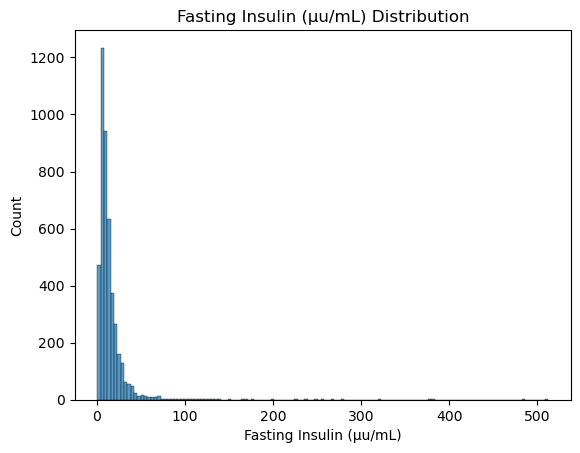

In [55]:
sns.histplot(data=df_i, x='insulin_μu_ml')
plt.title('Fasting Insulin (μu/mL) Distribution')
plt.ylabel('Count')
plt.xlabel('Fasting Insulin (μu/mL)')
plt.show()

In [56]:
df_i['insulin_μu_ml'].quantile([.95,.99])

0.95    37.3780
0.99    84.0416
Name: insulin_μu_ml, dtype: float64

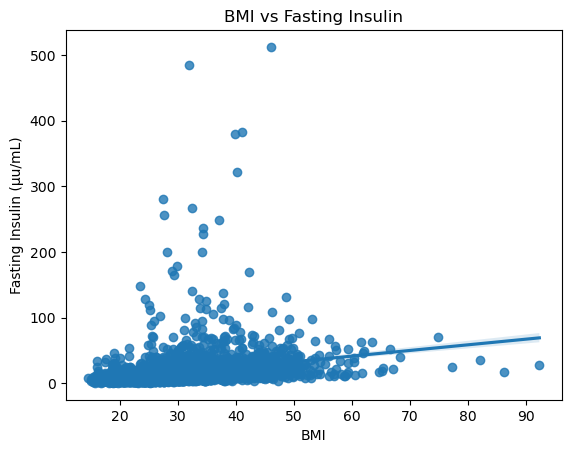

In [57]:
sns.regplot(data=df_i, x='bmi', y='insulin_μu_ml')
plt.title('BMI vs Fasting Insulin')
plt.xlabel('BMI')
plt.ylabel('Fasting Insulin (μu/mL)')
plt.show()

In [58]:
df_i[['bmi','insulin_μu_ml']].corr()

,bmi,insulin_μu_ml
bmi,1.000000,0.305019
insulin_μu_ml,0.305019,1.000000


In [59]:
stats.pearsonr(df_i['bmi'], df_i['insulin_μu_ml'])

PearsonRResult(statistic=np.float64(0.3050191852897171), pvalue=np.float64(3.9180267873581596e-98))

#### Gender Stratification

**Males**

In [60]:
df_i['gender_label']=df_i['gender'].map({1:'Male',2:'Female'})

In [61]:
df_i_male = df_i[df_i['gender'] == 1]
df_i_female = df_i[df_i['gender'] == 2]

In [62]:
df_i_male.describe()

,participant_id,insulin_μu_ml,insulin_pmol_l,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,2206.000000,2206.000000,2206.000000,2206.000000,2206.0,2206.000000,2206.000000,2206.000000
mean,117237.268812,14.754791,88.508577,28.352312,1.0,45.632820,3.465095,113.708069
std,4461.798370,22.146072,132.845444,6.604259,0.0,20.842097,1.637266,38.099869
min,109271.000000,0.460000,4.260000,15.100000,1.0,12.000000,1.000000,64.000000
25%,113378.250000,6.122500,36.735000,23.900000,1.0,26.000000,3.000000,97.000000
50%,117398.000000,9.795000,58.860000,27.550000,1.0,47.000000,3.000000,103.500000
75%,121059.250000,16.285000,97.710000,31.700000,1.0,63.000000,4.000000,114.000000
max,124822.000000,382.500000,2295.000000,86.200000,1.0,80.000000,7.000000,524.000000


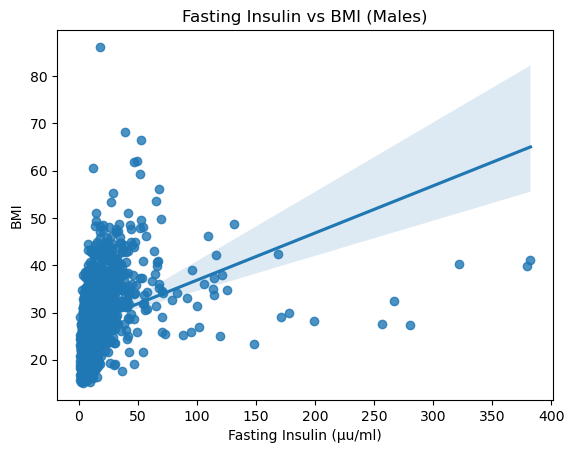

In [63]:
sns.regplot(data=df_i_male, x='insulin_μu_ml', y='bmi')
plt.title('Fasting Insulin vs BMI (Males)')
plt.xlabel('Fasting Insulin (μu/ml)')
plt.ylabel('BMI')
plt.show()

In [64]:
stats.pearsonr(df_i_male['insulin_μu_ml'], df_i_male['bmi'])

PearsonRResult(statistic=np.float64(0.3345208292848456), pvalue=np.float64(8.07306853676744e-59))

The average fasting insulin level in the male cohort is 14.7 μu/ml. Average BMI is 28.3. The maximum fasting insulin value is 382.5 μu/ml. 

The Pearson correlation coefficient is 0.33, which is slightly higher than the overall correlation in the entire cohort, although not statistically or clinically signinificant of a difference. 

**Females**

In [65]:
df_i_female.describe()

,participant_id,insulin_μu_ml,insulin_pmol_l,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,2323.000000,2323.000000,2323.000000,2323.000000,2323.0,2323.000000,2323.000000,2323.000000
mean,117082.606543,14.844167,88.686612,29.994059,2.0,45.240207,3.474387,108.829531
std,4477.666781,21.387609,120.069598,8.550982,0.0,20.009967,1.632627,34.062809
min,109264.000000,1.110000,6.660000,14.600000,2.0,12.000000,1.000000,47.000000
25%,113263.000000,6.525000,39.150000,24.000000,2.0,28.000000,3.000000,94.000000
50%,117045.000000,10.350000,62.520000,28.400000,2.0,46.000000,3.000000,100.000000
75%,120883.500000,16.880000,101.280000,34.400000,2.0,61.000000,4.000000,110.000000
max,124813.000000,512.500000,3075.000000,92.300000,2.0,80.000000,7.000000,389.000000


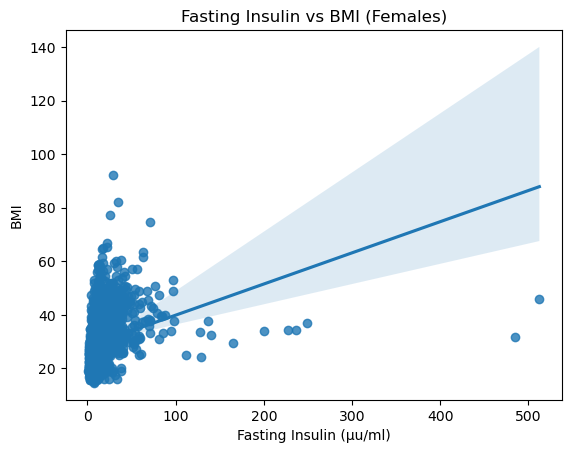

In [66]:
sns.regplot(data=df_i_female, x='insulin_μu_ml',y='bmi')
plt.title('Fasting Insulin vs BMI (Females)')
plt.xlabel('Fasting Insulin (μu/ml)')
plt.ylabel('BMI')
plt.show()

In [67]:
stats.pearsonr(df_i_female['insulin_μu_ml'], df_i_female['bmi'])

PearsonRResult(statistic=np.float64(0.2909944390793673), pvalue=np.float64(1.44482500115589e-46))

The female average BMI is 29.9. Maximum BMI is 92.3. The average fasting insulin level in the female cohort is 14.8, which is not different from the male cohort. The maximum fasting insulin level is 512.5, which is higher than the maximum value in the male cohort.

The Pearson correlation coefficient between fasting insulin levels and BMI in the female cohort is 0.29, which again, is not significantly different from the overall correlation with both male and female cohorts combined. The correlation is slightly lower compared to the male population but it is neither clinically nor statistically significant of a difference. 

### Hemoglobin A1c

Hemoglobin A1c (HgbA1c) is a way to diagnose diabetes, as it measures the average blood glucose saturation level in the past 3 months from the day of the blood draw. The ranges for the A1c is as follows:

* under 5.7% = normal
* 5.7-6.4% = prediabetes
* above 6.5% = diabetes

In [68]:
df_h.head()

,Unnamed: 0,participant_id,glycohemoglobin_percent
0,0,109264.0,5.3
1,1,109266.0,5.2
2,2,109271.0,5.6
3,3,109273.0,5.1
4,4,109274.0,5.7


In [69]:
df_h = df_h.merge(df, on='participant_id')

In [70]:
df_h = df_h.drop('Unnamed: 0', axis=1)

In [71]:
df_h.isna().sum()

participant_id             0
glycohemoglobin_percent    0
bmi                        0
gender                     0
age_year                   0
race                       0
fasting_glucose_mg_dl      0
gender_label               0
dtype: int64

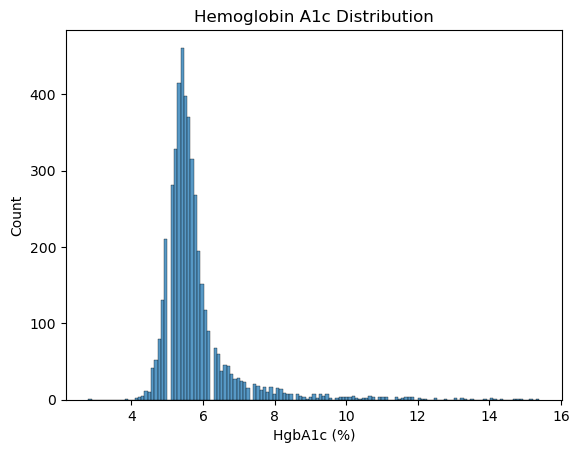

In [72]:
sns.histplot(data=df_h, x='glycohemoglobin_percent')
plt.title('Hemoglobin A1c Distribution')
plt.xlabel('HgbA1c (%)')
plt.ylabel('Count')
plt.show()

In [73]:
df_h.describe()

,participant_id,glycohemoglobin_percent,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,4647.000000,4647.000000,4647.000000,4647.000000,4647.000000,4647.000000,4647.000000
mean,117148.731440,5.789176,29.155821,1.514310,45.384549,3.477943,111.086507
std,4476.440806,1.106698,7.697477,0.499849,20.505356,1.634058,36.165941
min,109264.000000,2.800000,14.600000,1.000000,12.000000,1.000000,47.000000
25%,113306.000000,5.300000,23.900000,1.000000,27.000000,3.000000,95.000000
50%,117204.000000,5.500000,27.900000,2.000000,46.000000,3.000000,102.000000
75%,120992.500000,5.900000,33.000000,2.000000,62.000000,4.000000,112.000000
max,124822.000000,15.400000,92.300000,2.000000,80.000000,7.000000,524.000000


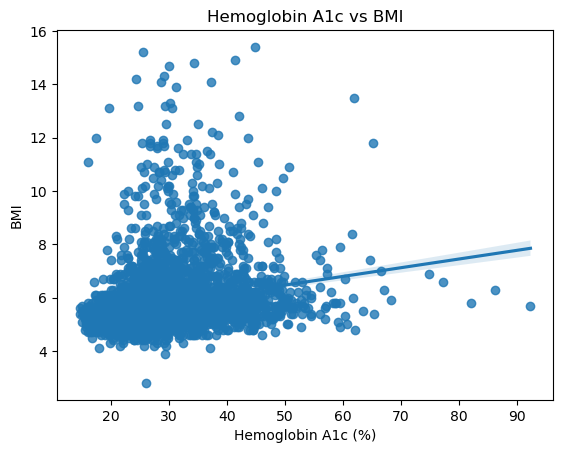

In [74]:
sns.regplot(data=df_h, x='bmi',y='glycohemoglobin_percent')
plt.title('Hemoglobin A1c vs BMI')
plt.xlabel('Hemoglobin A1c (%)')
plt.ylabel('BMI')
plt.show()

In [75]:
df_h[['bmi','glycohemoglobin_percent']].corr()

,bmi,glycohemoglobin_percent
bmi,1.000000,0.226822
glycohemoglobin_percent,0.226822,1.000000


In [76]:
stats.pearsonr(df_h['bmi'],df_h['glycohemoglobin_percent'])

PearsonRResult(statistic=np.float64(0.2268220029144073), pvalue=np.float64(2.7246105944008264e-55))

#### Gender Stratification

**Male**

In [77]:
df_h_male = df_h[df_h['gender'] ==1]
df_h_female = df_h[df_h['gender'] ==2]

In [78]:
df_h_male.describe()

,participant_id,glycohemoglobin_percent,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,2257.000000,2257.000000,2257.000000,2257.0,2257.000000,2257.000000,2257.000000
mean,117233.075764,5.809526,28.285778,1.0,45.661498,3.468764,113.677891
std,4469.204533,1.125306,6.602354,0.0,20.894570,1.634627,38.269081
min,109271.000000,4.100000,14.600000,1.0,12.000000,1.000000,64.000000
25%,113370.000000,5.300000,23.900000,1.0,26.000000,3.000000,97.000000
50%,117383.000000,5.500000,27.500000,1.0,47.000000,3.000000,103.000000
75%,121073.000000,5.900000,31.600000,1.0,63.000000,4.000000,114.000000
max,124822.000000,14.900000,86.200000,1.0,80.000000,7.000000,524.000000


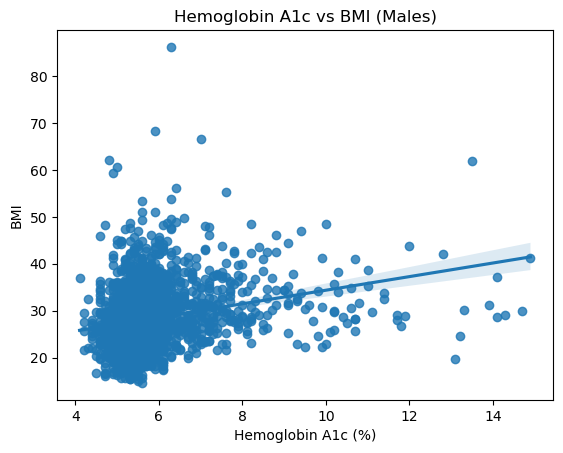

In [79]:
sns.regplot(data=df_h_male,x='glycohemoglobin_percent',y='bmi')
plt.title('Hemoglobin A1c vs BMI (Males)')
plt.xlabel('Hemoglobin A1c (%)')
plt.ylabel('BMI')
plt.show()

In [80]:
stats.pearsonr(df_h_male['glycohemoglobin_percent'], df_h_male['bmi'])

PearsonRResult(statistic=np.float64(0.2469245549312831), pvalue=np.float64(1.0593364955982484e-32))

The male cohort average hemoglobin A1c percentage is 5.8, which is in the prediabetes range. The maximum hemoglobin A1c in the male cohort is 14.9%. 

The correlation coefficient in the male cohort is 0.24 vs the overall cohort which is 0.22, again not significantly different.

**Females**

In [81]:
df_h_female.describe()

,participant_id,glycohemoglobin_percent,bmi,gender,age_year,race,fasting_glucose_mg_dl
count,2390.000000,2390.000000,2390.000000,2390.0,2390.000000,2390.000000,2390.000000
mean,117069.080753,5.769958,29.977448,2.0,45.123013,3.486611,108.639331
std,4482.741532,1.088719,8.524888,0.0,20.131774,1.633814,33.887393
min,109264.000000,2.800000,14.600000,2.0,12.000000,1.000000,47.000000
25%,113249.500000,5.200000,23.925000,2.0,28.000000,3.000000,93.250000
50%,117060.000000,5.500000,28.400000,2.0,46.000000,3.000000,100.000000
75%,120878.500000,5.900000,34.400000,2.0,61.000000,4.000000,110.000000
max,124813.000000,15.400000,92.300000,2.0,80.000000,7.000000,389.000000


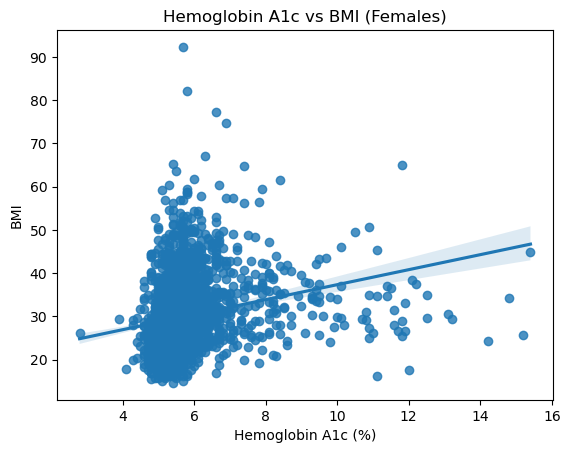

In [82]:
sns.regplot(data=df_h_female, x='glycohemoglobin_percent',y='bmi')
plt.title('Hemoglobin A1c vs BMI (Females)')
plt.xlabel('Hemoglobin A1c (%)')
plt.ylabel('BMI')
plt.show()

In [83]:
stats.pearsonr(df_h_female['glycohemoglobin_percent'], df_h_female['bmi'])

PearsonRResult(statistic=np.float64(0.2217189596470988), pvalue=np.float64(5.300282195294181e-28))

The average hemoglobin A1c levels in the female cohort is 15.4, which is slightly higher than the male cohort. The correlation coefficient in the female cohort is 0.22, not significantly different from the overall value (0.22) and the male cohort (0.24). 

### Multivariable Regression

All three carbohydrate metabolism markers are weakly and positively correlated with BMI. Multivariate regression could be useful with these three lab results. 

All three lab values did not show significant difference in the biological sex of the patients. The sex will be added as a covariate for the model rather than running two separate models.

In [84]:
df_all = df.merge(df_i, on='participant_id').merge(df_h, on='participant_id')

In [85]:
df_all.head()

,participant_id,bmi_x,gender_x,age_year_x,race_x,fasting_glucose_mg_dl_x,gender_label_x,insulin_μu_ml,insulin_pmol_l,bmi_y,...,race_y,fasting_glucose_mg_dl_y,gender_label_y,glycohemoglobin_percent,bmi,gender,age_year,race,fasting_glucose_mg_dl,gender_label
0,109264.0,17.6,2.0,13.0,1.0,97.0,Female,6.05,36.30,17.6,...,1.0,97.0,Female,5.3,17.6,2.0,13.0,1.0,97.0,Female
1,109271.0,29.7,1.0,49.0,3.0,103.0,Male,16.96,101.76,29.7,...,3.0,103.0,Male,5.6,29.7,1.0,49.0,3.0,103.0,Male
2,109274.0,30.2,1.0,68.0,7.0,154.0,Male,13.52,81.12,30.2,...,7.0,154.0,Male,5.7,30.2,1.0,68.0,7.0,154.0,Male
3,109277.0,18.6,2.0,12.0,1.0,92.0,Female,6.44,38.64,18.6,...,1.0,92.0,Female,5.3,18.6,2.0,12.0,1.0,92.0,Female
4,109282.0,26.6,1.0,76.0,3.0,95.0,Male,7.49,44.94,26.6,...,3.0,95.0,Male,5.5,26.6,1.0,76.0,3.0,95.0,Male


In [86]:
df_all.columns

Index(['participant_id', 'bmi_x', 'gender_x', 'age_year_x', 'race_x',
       'fasting_glucose_mg_dl_x', 'gender_label_x', 'insulin_μu_ml',
       'insulin_pmol_l', 'bmi_y', 'gender_y', 'age_year_y', 'race_y',
       'fasting_glucose_mg_dl_y', 'gender_label_y', 'glycohemoglobin_percent',
       'bmi', 'gender', 'age_year', 'race', 'fasting_glucose_mg_dl',
       'gender_label'],
      dtype='object')

In [87]:
df_all = df_all.drop(['bmi_x', 'gender_x', 'age_year_x', 'race_x',
       'fasting_glucose_mg_dl_x', 'gender_label_x','bmi_y', 'gender_y', 'age_year_y', 'race_y',
       'fasting_glucose_mg_dl_y', 'gender_label_y'], axis=1)

In [88]:
df_all.head()

,participant_id,insulin_μu_ml,insulin_pmol_l,glycohemoglobin_percent,bmi,gender,age_year,race,fasting_glucose_mg_dl,gender_label
0,109264.0,6.05,36.30,5.3,17.6,2.0,13.0,1.0,97.0,Female
1,109271.0,16.96,101.76,5.6,29.7,1.0,49.0,3.0,103.0,Male
2,109274.0,13.52,81.12,5.7,30.2,1.0,68.0,7.0,154.0,Male
3,109277.0,6.44,38.64,5.3,18.6,2.0,12.0,1.0,92.0,Female
4,109282.0,7.49,44.94,5.5,26.6,1.0,76.0,3.0,95.0,Male


In [89]:
df_all[['bmi','insulin_μu_ml','glycohemoglobin_percent','fasting_glucose_mg_dl']].corr()

,bmi,insulin_μu_ml,glycohemoglobin_percent,fasting_glucose_mg_dl
bmi,1.000000,0.304812,0.224192,0.200858
insulin_μu_ml,0.304812,1.000000,0.205301,0.181131
glycohemoglobin_percent,0.224192,0.205301,1.000000,0.842605
fasting_glucose_mg_dl,0.200858,0.181131,0.842605,1.000000


The correlation table for all carbohydrate metabolism variables shows a strong correlation between fasting glucose and hemoglobin A1c (0.84) which makes sense. Although this is a cross sectional observational study, hemoglobin A1c would be better to keep to show how the glycemic control is over a longer period of time. The hemoglobin A1c level is a more stable measurement of the blood glucose levels rather than a single point fasting glucose. 

In [90]:
df_all.shape

(4521, 10)

In [91]:
import statsmodels.api as sm

X = df_all[['insulin_μu_ml','glycohemoglobin_percent', 'gender']]
y = df_all['bmi']

X = sm.add_constant(X)

model = sm.OLS(y,X).fit()

print(model.summary())

ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (C:\Users\Rachel\anaconda3\Lib\site-packages\scipy\_lib\_util.py)

The multivariable regression model shows that the insulin and hemoglobin A1c explain about 12% of the BMI variance. Considering that metabolism is also affected by nutrition and activity levels, this number makes sense. 

In [92]:
import scipy
import statsmodels

print(scipy.__version__)
print(statsmodels.__version__)

1.17.0
0.14.4
